# Hybrid Alpha Tuning

Grid-searches the dense/BM25 balance (`alpha`) over the **491-question `eval_set_clean.json`** and stores results as a DataFrame for visualization.

**alpha = 1.0** → pure dense  
**alpha = 0.0** → pure BM25

Metrics:
- **Hit@1 / Hit@3 / Hit@5** — section-level: did a chunk from the correct section appear in top-K?
- **MRR** — reciprocal rank of the first chunk from the correct section
- **HN Contamination** — fraction of queries where a hard negative chunk outranked the positive section

In [ ]:
import os
import sys
import re
import json
import numpy as np
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

# Works whether the notebook is run from its own directory or from project root
PROJECT_ROOT = Path(".").resolve().parent if Path(".").resolve().name == "notebooks" else Path(".").resolve()

load_dotenv(PROJECT_ROOT / ".env.local")
os.environ.setdefault("USE_TF", "0")

sys.path.insert(0, str(PROJECT_ROOT / "src" / "retrieval"))

from pinecone import Pinecone
from sentence_transformers import SentenceTransformer
from retrieve import retrieve, load_chunk_store, load_bm25, EMBED_MODEL

CHUNK_STORE_PATH = PROJECT_ROOT / "data" / "processed" / "chunk_store.json"
BM25_PARAMS_PATH = PROJECT_ROOT / "data" / "processed" / "bm25_params.json"
EVAL_SET_PATH    = PROJECT_ROOT / "src" / "eval" / "eval_set_clean.json"
TOP_K = 5

# Random sample size for alpha tuning — faster, statistically stable at ±3-4%.
# Set to None to use the full eval set for a final confirmation run.
SAMPLE_SIZE = 100

In [11]:
# ── Load shared resources (once) ────────────────────────────────────────────
print(f"Loading model '{EMBED_MODEL}'...")
model = SentenceTransformer(EMBED_MODEL)

print("Loading BM25 encoder...")
bm25 = load_bm25(BM25_PARAMS_PATH)

print("Loading chunk store...")
store = load_chunk_store(CHUNK_STORE_PATH)
print(f"  {len(store)} chunks")

pinecone_key = os.environ.get("PINECONE_API_KEY")
assert pinecone_key, "PINECONE_API_KEY not set"
pc    = Pinecone(api_key=pinecone_key)
index = pc.Index("cba")
print(f"Pinecone: {index.describe_index_stats()['total_vector_count']} vectors")

Loading model 'multi-qa-mpnet-base-dot-v1'...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading BM25 encoder...
Loading chunk store...
  1349 chunks
Pinecone: 1349 vectors


In [12]:
# ── Load eval set ────────────────────────────────────────────────────────────
_SECTION_NUM_RE = re.compile(r'^(Section\s+\d+[\w.]*)', re.IGNORECASE)

def _section_key(section: str) -> str:
    m = _SECTION_NUM_RE.match(section.strip())
    return m.group(1).rstrip(".") if m else section.strip().rstrip(".")

def load_eval_set(path: Path) -> list[dict]:
    entries = json.loads(path.read_text())
    parsed = []
    for e in entries:
        chunk_id = e.get("positive_chunk_id", "")
        article  = e.get("article", "")
        section  = e.get("section", "")
        if not (chunk_id and article and section):
            continue
        parsed.append({
            "question":          e["question"],
            "pos_chunk_id":      chunk_id,
            "pos_article":       article,
            "pos_section_key":   _section_key(section),
            "hard_negative_ids": set(e.get("hard_negative_ids", [])),
        })
    return parsed

eval_entries = load_eval_set(EVAL_SET_PATH)
if SAMPLE_SIZE:
    import random; random.seed(42)
    eval_entries = random.sample(eval_entries, min(SAMPLE_SIZE, len(eval_entries)))

print(f"{len(eval_entries)} eval entries loaded from {EVAL_SET_PATH.name}")

490 eval entries loaded from eval_set_clean.json


In [13]:
# ── IR metric helper ──────────────────────────────────────────────────────────
def ir_metrics(results, pos_article: str, pos_section_key: str, hard_negative_ids: set) -> dict:
    """
    Section-level matching: a result is a hit if (article, section_key) matches the positive.
    HN contamination: 1.0 if any hard negative chunk appears ranked above the positive section.
    """
    hit1 = hit3 = hit5 = mrr = 0.0
    pos_rank = None
    hn_best_rank = None

    for r in results:
        key = (r.article, _section_key(r.section))

        if key == (pos_article, pos_section_key):
            pos_rank = r.rank
            if r.rank == 1:  hit1 = 1.0
            if r.rank <= 3:  hit3 = 1.0
            if r.rank <= 5:  hit5 = 1.0
            if mrr == 0.0:   mrr  = 1.0 / r.rank

        if r.chunk_id in hard_negative_ids:
            if hn_best_rank is None or r.rank < hn_best_rank:
                hn_best_rank = r.rank

    # HN outranks positive (or positive was missed but HN appeared)
    hn_contamination = 1.0 if (
        hn_best_rank is not None and (pos_rank is None or hn_best_rank < pos_rank)
    ) else 0.0

    return {"hit1": hit1, "hit3": hit3, "hit5": hit5, "mrr": mrr, "hn_contamination": hn_contamination}

In [14]:
# ── Coarse alpha sweep: 0.0 → 1.0 in steps of 0.1 ───────────────────────────
# Runtime: ~491 queries × 11 alphas ≈ 5,400 Pinecone calls (~15-25 min)
# Set SAMPLE_SIZE in cell 1 to reduce this for a quick test.
ALPHAS = [round(a, 2) for a in np.arange(0.0, 1.01, 0.1)]

rows = []
for alpha in ALPHAS:
    metrics_per_q = []
    for entry in eval_entries:
        results = retrieve(
            entry["question"], top_k=TOP_K, alpha=alpha,
            model=model, bm25=bm25, index=index, chunk_store=store,
        )
        metrics_per_q.append(ir_metrics(
            results,
            entry["pos_article"],
            entry["pos_section_key"],
            entry["hard_negative_ids"],
        ))

    n = len(metrics_per_q)
    row = {
        "alpha":          alpha,
        "hit1":           sum(m["hit1"]           for m in metrics_per_q) / n,
        "hit3":           sum(m["hit3"]           for m in metrics_per_q) / n,
        "hit5":           sum(m["hit5"]           for m in metrics_per_q) / n,
        "mrr":            sum(m["mrr"]            for m in metrics_per_q) / n,
        "hn_contamination": sum(m["hn_contamination"] for m in metrics_per_q) / n,
    }
    rows.append(row)
    print(f"alpha={alpha:.2f}  Hit@1={row['hit1']:.3f}  Hit@5={row['hit5']:.3f}  "
          f"MRR={row['mrr']:.3f}  HN-Contam={row['hn_contamination']:.3f}")

df_coarse = pd.DataFrame(rows)
df_coarse

alpha=0.00  Hit@1=0.608  Hit@5=0.824  MRR=0.690  HN-Contam=0.010
alpha=0.10  Hit@1=0.684  Hit@5=0.863  MRR=0.759  HN-Contam=0.008
alpha=0.20  Hit@1=0.653  Hit@5=0.857  MRR=0.740  HN-Contam=0.006
alpha=0.30  Hit@1=0.643  Hit@5=0.855  MRR=0.732  HN-Contam=0.010
alpha=0.40  Hit@1=0.643  Hit@5=0.851  MRR=0.729  HN-Contam=0.010
alpha=0.50  Hit@1=0.641  Hit@5=0.851  MRR=0.728  HN-Contam=0.010
alpha=0.60  Hit@1=0.639  Hit@5=0.851  MRR=0.726  HN-Contam=0.010
alpha=0.70  Hit@1=0.637  Hit@5=0.849  MRR=0.723  HN-Contam=0.010
alpha=0.80  Hit@1=0.637  Hit@5=0.851  MRR=0.724  HN-Contam=0.010
alpha=0.90  Hit@1=0.637  Hit@5=0.851  MRR=0.724  HN-Contam=0.010
alpha=1.00  Hit@1=0.637  Hit@5=0.851  MRR=0.724  HN-Contam=0.010


,alpha,hit1,hit3,hit5,mrr,hn_contamination
0,0.0,0.608163,0.767347,0.824490,0.690136,0.010204
1,0.1,0.683673,0.838776,0.863265,0.758571,0.008163
2,0.2,0.653061,0.832653,0.857143,0.739966,0.006122
3,0.3,0.642857,0.826531,0.855102,0.732041,0.010204
4,0.4,0.642857,0.822449,0.851020,0.729184,0.010204
5,0.5,0.640816,0.818367,0.851020,0.727721,0.010204
6,0.6,0.638776,0.818367,0.851020,0.726361,0.010204
7,0.7,0.636735,0.816327,0.848980,0.723299,0.010204
8,0.8,0.636735,0.814286,0.851020,0.723878,0.010204
9,0.9,0.636735,0.814286,0.851020,0.723776,0.010204


In [15]:
# ── Fine sweep around best MRR alpha ─────────────────────────────────────────
best_alpha_coarse = df_coarse.loc[df_coarse["hit3"].idxmax(), "alpha"]
print(f"Best alpha (coarse, by MRR): {best_alpha_coarse}")

fine_low  = max(0.0, best_alpha_coarse - 0.1)
fine_high = min(1.0, best_alpha_coarse + 0.1)
ALPHAS_FINE = [round(a, 2) for a in np.arange(fine_low, fine_high + 0.01, 0.02)]

rows_fine = []
for alpha in ALPHAS_FINE:
    metrics_per_q = []
    for entry in eval_entries:
        results = retrieve(
            entry["question"], top_k=TOP_K, alpha=alpha,
            model=model, bm25=bm25, index=index, chunk_store=store,
        )
        metrics_per_q.append(ir_metrics(
            results,
            entry["pos_article"],
            entry["pos_section_key"],
            entry["hard_negative_ids"],
        ))

    n = len(metrics_per_q)
    row = {
        "alpha":          alpha,
        "hit1":           sum(m["hit1"]           for m in metrics_per_q) / n,
        "hit3":           sum(m["hit3"]           for m in metrics_per_q) / n,
        "hit5":           sum(m["hit5"]           for m in metrics_per_q) / n,
        "mrr":            sum(m["mrr"]            for m in metrics_per_q) / n,
        "hn_contamination": sum(m["hn_contamination"] for m in metrics_per_q) / n,
    }
    rows_fine.append(row)
    print(f"alpha={alpha:.2f}  Hit@1={row['hit1']:.3f}  MRR={row['mrr']:.3f}  "
          f"HN-Contam={row['hn_contamination']:.3f}")

df_fine = pd.DataFrame(rows_fine)
df_fine

Best alpha (coarse, by MRR): 0.1
alpha=0.00  Hit@1=0.608  MRR=0.690  HN-Contam=0.010
alpha=0.02  Hit@1=0.708  MRR=0.778  HN-Contam=0.010
alpha=0.04  Hit@1=0.710  MRR=0.778  HN-Contam=0.010
alpha=0.06  Hit@1=0.706  MRR=0.772  HN-Contam=0.010
alpha=0.08  Hit@1=0.702  MRR=0.768  HN-Contam=0.008
alpha=0.10  Hit@1=0.684  MRR=0.759  HN-Contam=0.008
alpha=0.12  Hit@1=0.673  MRR=0.753  HN-Contam=0.008
alpha=0.14  Hit@1=0.667  MRR=0.749  HN-Contam=0.008
alpha=0.16  Hit@1=0.659  MRR=0.744  HN-Contam=0.008
alpha=0.18  Hit@1=0.653  MRR=0.741  HN-Contam=0.006
alpha=0.20  Hit@1=0.653  MRR=0.740  HN-Contam=0.006


,alpha,hit1,hit3,hit5,mrr,hn_contamination
0,0.00,0.608163,0.767347,0.824490,0.690136,0.010204
1,0.02,0.708163,0.846939,0.879592,0.777755,0.010204
2,0.04,0.710204,0.842857,0.873469,0.777789,0.010204
3,0.06,0.706122,0.842857,0.865306,0.771871,0.010204
4,0.08,0.702041,0.840816,0.863265,0.768129,0.008163
5,0.10,0.683673,0.838776,0.863265,0.758571,0.008163
6,0.12,0.673469,0.836735,0.861224,0.753469,0.008163
7,0.14,0.667347,0.836735,0.861224,0.748946,0.008163
8,0.16,0.659184,0.834694,0.859184,0.743707,0.008163
9,0.18,0.653061,0.834694,0.859184,0.740646,0.006122


In [7]:
# ── Best alpha summary ────────────────────────────────────────────────────────
df_all = (
    pd.concat([df_coarse, df_fine])
    .drop_duplicates(subset="alpha")
    .sort_values("alpha")
    .reset_index(drop=True)
)

metrics = ["hit1", "hit3", "hit5", "mrr", "hn_contamination"]
best = {}
for metric in metrics:
    # For HN contamination lower is better
    if metric == "hn_contamination":
        idx = df_all[metric].idxmin()
        best[metric] = (df_all.loc[idx, "alpha"], df_all.loc[idx, metric])
        print(f"Best {metric:16s}: alpha={best[metric][0]:.2f}  value={best[metric][1]:.4f}  (lower is better)")
    else:
        idx = df_all[metric].idxmax()
        best[metric] = (df_all.loc[idx, "alpha"], df_all.loc[idx, metric])
        print(f"Best {metric:16s}: alpha={best[metric][0]:.2f}  value={best[metric][1]:.4f}")

best_alpha = best["mrr"][0]
print(f"\nRecommended HYBRID_ALPHA (by MRR): {best_alpha}")

Best hit1            : alpha=0.04  value=0.7102
Best hit3            : alpha=0.02  value=0.8469
Best hit5            : alpha=0.02  value=0.8796
Best mrr             : alpha=0.04  value=0.7778
Best hn_contamination: alpha=0.18  value=0.0061  (lower is better)

Recommended HYBRID_ALPHA (by MRR): 0.04


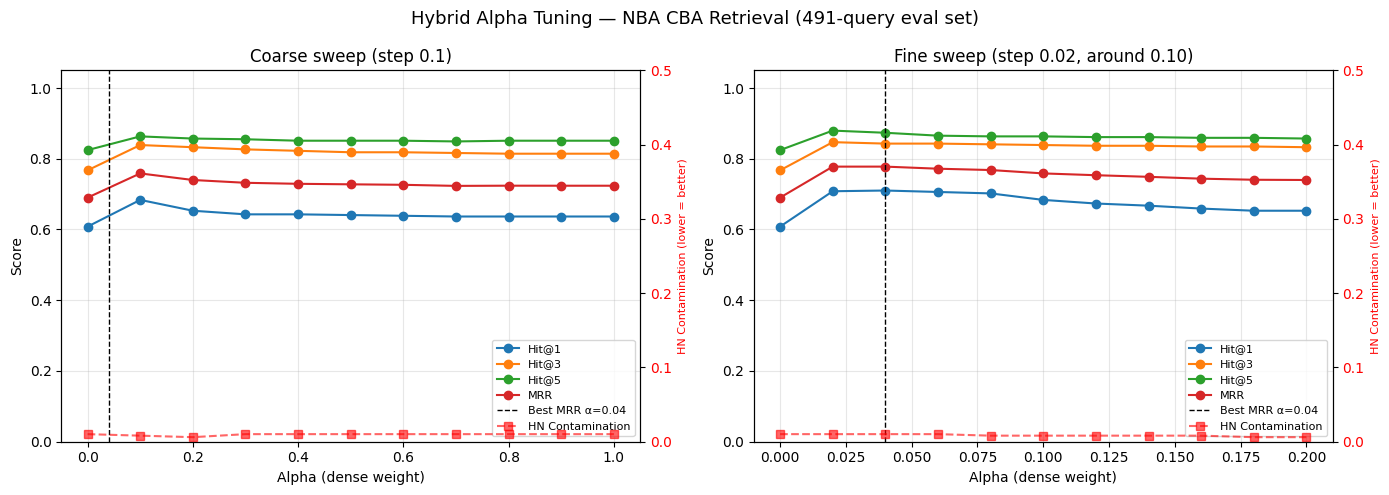

Plot saved to tune_alpha_results.png


In [8]:
# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Hybrid Alpha Tuning — NBA CBA Retrieval (491-query eval set)", fontsize=13)

retrieval_metrics = ["hit1", "hit3", "hit5", "mrr"]
labels = {"hit1": "Hit@1", "hit3": "Hit@3", "hit5": "Hit@5", "mrr": "MRR", "hn_contamination": "HN Contamination"}

for ax, df, title in [
    (axes[0], df_coarse, "Coarse sweep (step 0.1)"),
    (axes[1], df_fine,   f"Fine sweep (step 0.02, around {best_alpha_coarse:.2f})"),
]:
    for m in retrieval_metrics:
        ax.plot(df["alpha"], df[m], marker="o", label=labels[m])

    # HN contamination on a secondary y-axis (lower is better, inverted scale)
    ax2 = ax.twinx()
    ax2.plot(df["alpha"], df["hn_contamination"], marker="s", linestyle="--",
             color="red", alpha=0.6, label=labels["hn_contamination"])
    ax2.set_ylabel("HN Contamination (lower = better)", color="red", fontsize=8)
    ax2.tick_params(axis="y", labelcolor="red")
    ax2.set_ylim(0, 0.5)

    ax.axvline(x=best_alpha, color="black", linestyle="--", linewidth=1,
               label=f"Best MRR α={best_alpha:.2f}")
    ax.set_xlabel("Alpha (dense weight)")
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
out_path = Path(__file__).parent / "tune_alpha_results.png" if "__file__" in dir() else Path("tune_alpha_results.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved to {out_path}")

In [9]:
# ── Update HYBRID_ALPHA in retrieve.py ───────────────────────────────────────
import re as _re

retrieve_path = PROJECT_ROOT / "src" / "retrieval" / "retrieve.py"
src = retrieve_path.read_text()
updated = _re.sub(
    r'(HYBRID_ALPHA\s*=\s*)([\d.]+)',
    lambda m: f'{m.group(1)}{best_alpha}',
    src,
)
retrieve_path.write_text(updated)
print(f"Updated HYBRID_ALPHA to {best_alpha} in src/retrieval/retrieve.py")

Updated HYBRID_ALPHA to 0.04 in src/retrieval/retrieve.py
